# Statistiques descriptives

Mise en pratique de la théorie !

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Lecture et manipulation du fichier

Nous allons étudider un fichier de données sur les prix de différents aliments au cours du temps. Les données viennent de la FAO (Food and Agriculture Organization of the United Nations).

[source](https://www.fao.org/worldfoodsituation/foodpricesindex/en/)

Lisez le fichier csv et affichez les 5 premières lignes du dataframe. Quels sont les noms des colonnes ? Quel est le type de chaque colonne ? Combien y a-t-il de lignes et de colonnes dans le dataframe ?

In [4]:
df = pd.read_csv('./food_price_indices_data_csv_feb_clean.csv')
df.head()

,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
0,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
1,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
2,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
3,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
4,1990-05,64.6,81.8,39.2,62.0,45.50,90.4


Vous remarquez qu'une colonne indique la date mais n'est pas reconnue comme une colonne de type date.
En regardant la documentation de la fonction `pd.read_csv()`, trouvez comment faire pour que cette colonne soit reconnue comme une colonne de type date dès la lecture du fichier csv.
Lisez à nouveau le fichier csv en utilisant cette option et vérifiez que la colonne de date est bien reconnue comme une colonne de type date.

In [ ]:
df = pd.read_csv('./food_price_indices_data_csv_feb_clean.csv', parse_dates=["Date"])
df

,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
0,1990-01-01,64.4,74.3,53.5,64.1,44.59,87.9
1,1990-02-01,64.7,76.8,52.2,62.2,44.50,90.7
2,1990-03-01,64.0,78.5,41.4,61.3,45.75,95.1
3,1990-04-01,66.0,81.2,48.4,62.8,44.02,94.3
4,1990-05-01,64.6,81.8,39.2,62.0,45.50,90.4
...,...,...,...,...,...,...,...
428,2025-09-01,128.6,127.9,147.2,104.9,167.90,99.4
429,2025-10-01,126.4,125.0,141.7,103.6,169.40,94.1
430,2025-11-01,125.2,125.4,136.2,105.5,165.00,88.6
431,2025-12-01,124.3,124.2,128.2,107.3,165.20,90.7


Mettez la date en index du dataframe et créez un graphique avec chacune des autres colonnes en fonction de la date.

Le graphique devrait ressembler à ça :

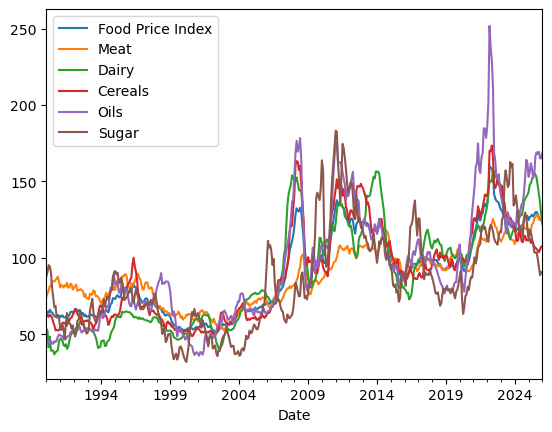

Indice : peut être fait en une ligne de code !

In [8]:
df = pd.read_csv('./food_price_indices_data_csv_feb_clean.csv', parse_dates=["Date"])
df.set_index("Date", inplace=True)
df

,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
Date,,,,,,
1990-01-01,64.4,74.3,53.5,64.1,44.59,87.9
1990-02-01,64.7,76.8,52.2,62.2,44.50,90.7
1990-03-01,64.0,78.5,41.4,61.3,45.75,95.1
1990-04-01,66.0,81.2,48.4,62.8,44.02,94.3
1990-05-01,64.6,81.8,39.2,62.0,45.50,90.4
...,...,...,...,...,...,...
2025-09-01,128.6,127.9,147.2,104.9,167.90,99.4
2025-10-01,126.4,125.0,141.7,103.6,169.40,94.1
2025-11-01,125.2,125.4,136.2,105.5,165.00,88.6


<Axes: xlabel='Date'>

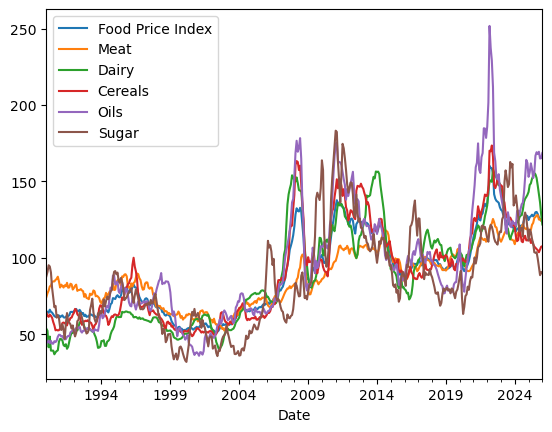

In [9]:
df.plot()

### Variations de l'indicateur synthétique **Food Price Index**

Que fait la commande .diff() ? A quoi sert-elle ? Que se passe-t-il si on l'applique à la colonne "Food Price Index" ?

In [12]:
df["Food Price Index"].diff()

Date
1990-01-01    NaN
1990-02-01    0.3
1990-03-01   -0.7
1990-04-01    2.0
1990-05-01   -1.4
             ... 
2025-09-01   -1.4
2025-10-01   -2.2
2025-11-01   -1.2
2025-12-01   -0.9
2026-01-01   -0.4
Name: Food Price Index, Length: 433, dtype: float64

In [13]:
df["Food Price Index"]

Date
1990-01-01     64.4
1990-02-01     64.7
1990-03-01     64.0
1990-04-01     66.0
1990-05-01     64.6
              ...  
2025-09-01    128.6
2025-10-01    126.4
2025-11-01    125.2
2025-12-01    124.3
2026-01-01    123.9
Name: Food Price Index, Length: 433, dtype: float64

Que fait la commande .pct_change() ? A quoi sert-elle ? Que se passe-t-il si on l'applique à la colonne "Food Price Index" ?

In [14]:
df["Food Price Index"].pct_change()

Date
1990-01-01         NaN
1990-02-01    0.004658
1990-03-01   -0.010819
1990-04-01    0.031250
1990-05-01   -0.021212
                ...   
2025-09-01   -0.010769
2025-10-01   -0.017107
2025-11-01   -0.009494
2025-12-01   -0.007188
2026-01-01   -0.003218
Name: Food Price Index, Length: 433, dtype: float64

Quelle est la moyenne du taux de variation mensuel de l'indice des prix alimentaires ? 

Indice : vous pouvez vous aider de df.apply() pour appliquer la fonction de votre choix à une colonne du dataframe voire de df.prod() pour calculer le produit de tous les éléments d'une série.

In [17]:
tx_variation = df["Food Price Index"].pct_change()

def geomoyenne(series):
    return (series + 1).prod() ** (1 / len(series)) - 1

geomoyenne(tx_variation.dropna()) * 100

np.float64(0.15158726722530602)

## 2. Statistiques univariées

Pour chaque colonne du dataframe, calculez les statistiques suivantes : moyenne, médiane, écart-type, minimum, maximum, 1er quartile et 3e quartile.

In [20]:
cols = df.columns

for col in cols:
    print(f"Statistiques pour la colonne {col} :")
    print(f"Moyenne : {df[col].mean()}")
    print(f"Médiane : {df[col].median()}")
    print(f"Ecart-type : {df[col].std()}")
    print(f"Minimum : {df[col].min()}")
    print(f"Maximum : {df[col].max()}")
    print(f"1er quartile : {df[col].quantile(0.25)}")
    print(f"3e quartile : {df[col].quantile(0.75)}")
    print("\n")

Statistiques pour la colonne Food Price Index :
Moyenne : 89.19561200923786
Médiane : 87.4
Ecart-type : 27.244837332172168
Minimum : 50.8
Maximum : 160.2
1er quartile : 64.7
3e quartile : 116.5


Statistiques pour la colonne Meat :
Moyenne : 87.53418013856813
Médiane : 85.2
Ecart-type : 18.575129861837887
Minimum : 52.3
Maximum : 127.9
1er quartile : 73.4
3e quartile : 101.6


Statistiques pour la colonne Dairy :
Moyenne : 88.75588914549652
Médiane : 81.8
Ecart-type : 34.97074198667786
Minimum : 36.8
Maximum : 158.2
1er quartile : 57.6
3e quartile : 117.2


Statistiques pour la colonne Cereals :
Moyenne : 89.66882217090068
Médiane : 88.4
Ecart-type : 31.579955444522493
Minimum : 48.6
Maximum : 173.5
1er quartile : 60.6
3e quartile : 111.6


Statistiques pour la colonne Oils :
Moyenne : 93.88900692840647
Médiane : 83.56
Ecart-type : 40.08155663286268
Minimum : 35.83
Maximum : 251.8
1er quartile : 63.91
3e quartile : 120.64


Statistiques pour la colonne Sugar :
Moyenne : 84.926327944572

## 3. Statistiques bivariées

A l'aide d'une matrice de corrélation, commentez les relations entre les prix des différents aliments. Quels aliments sont les plus liés entre eux ? Quels aliments sont les moins liés entre eux ?

<Axes: >

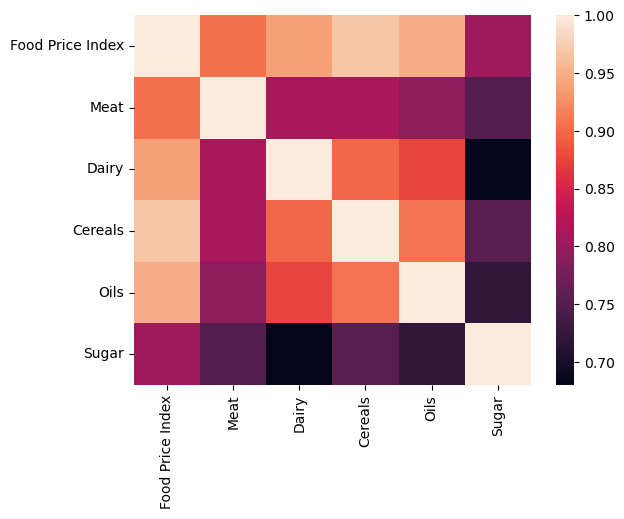

In [11]:
corr = df.corr()
sns.heatmap(corr)

## 4. (Bonus) Pratique de matplotlib

Reproduisez le graphique ci-dessous à l'aide de matplotlib, vous devrez utiliser des **subplots**.

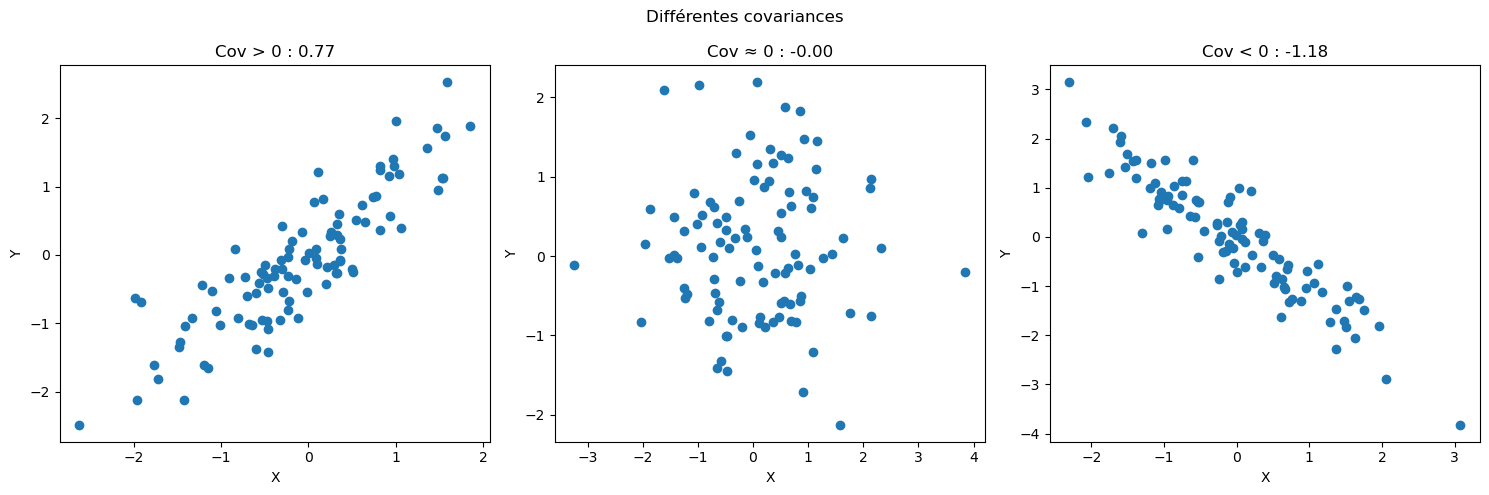

In [18]:

np.random.seed(42)  # pour reproductibilité

#  Covariance positive
x_pos = np.random.randn(100)
y_pos = x_pos + np.random.randn(100)*0.5  # corrélation positive
cov_pos = np.cov(x_pos, y_pos)[0,1]

#  Covariance nulle
x_zero = np.random.randn(100)
y_zero = np.random.randn(100)  # indépendant → covariance proche de 0
cov_zero = np.cov(x_zero, y_zero)[0,1]

#  Covariance négative
x_neg = np.random.randn(100)
y_neg = -x_neg + np.random.randn(100)*0.5  # corrélation négative
cov_neg = np.cov(x_neg, y_neg)[0,1]

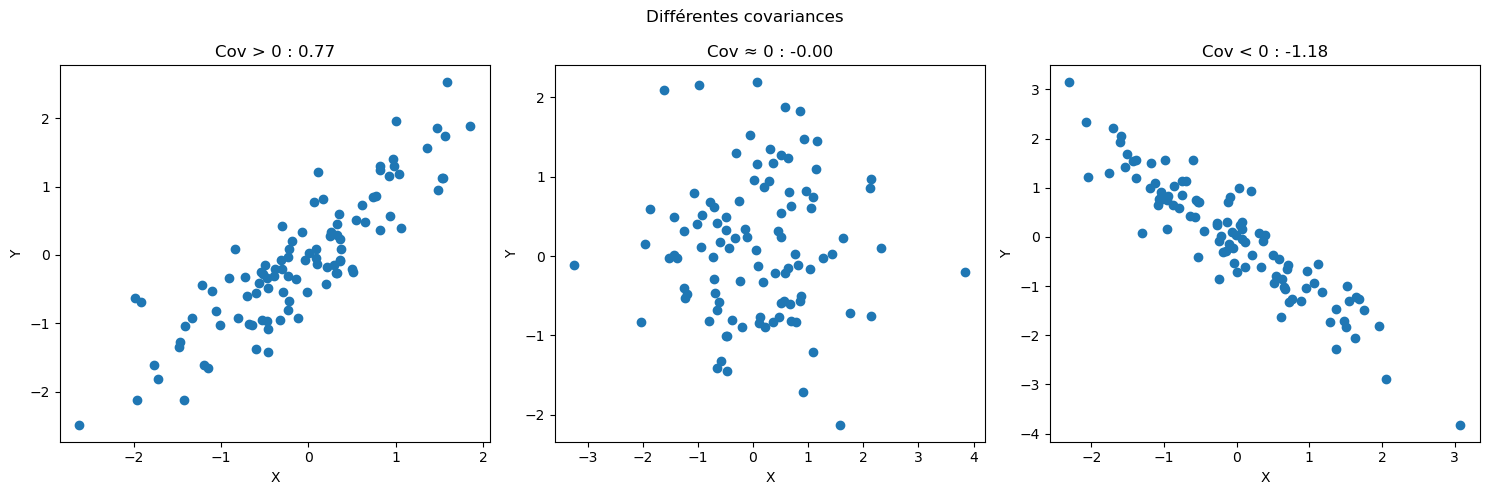

In [19]:

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].scatter(x_pos, y_pos)
axes[0].set_title(f"Cov > 0 : {cov_pos:.2f}")

axes[1].scatter(x_zero, y_zero)
axes[1].set_title(f"Cov ≈ 0 : {cov_zero:.2f}")

axes[2].scatter(x_neg, y_neg)
axes[2].set_title(f"Cov < 0 : {cov_neg:.2f}")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("Différentes covariances")
plt.tight_layout()
plt.show()